In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("41-housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# target value is median_house_value

In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

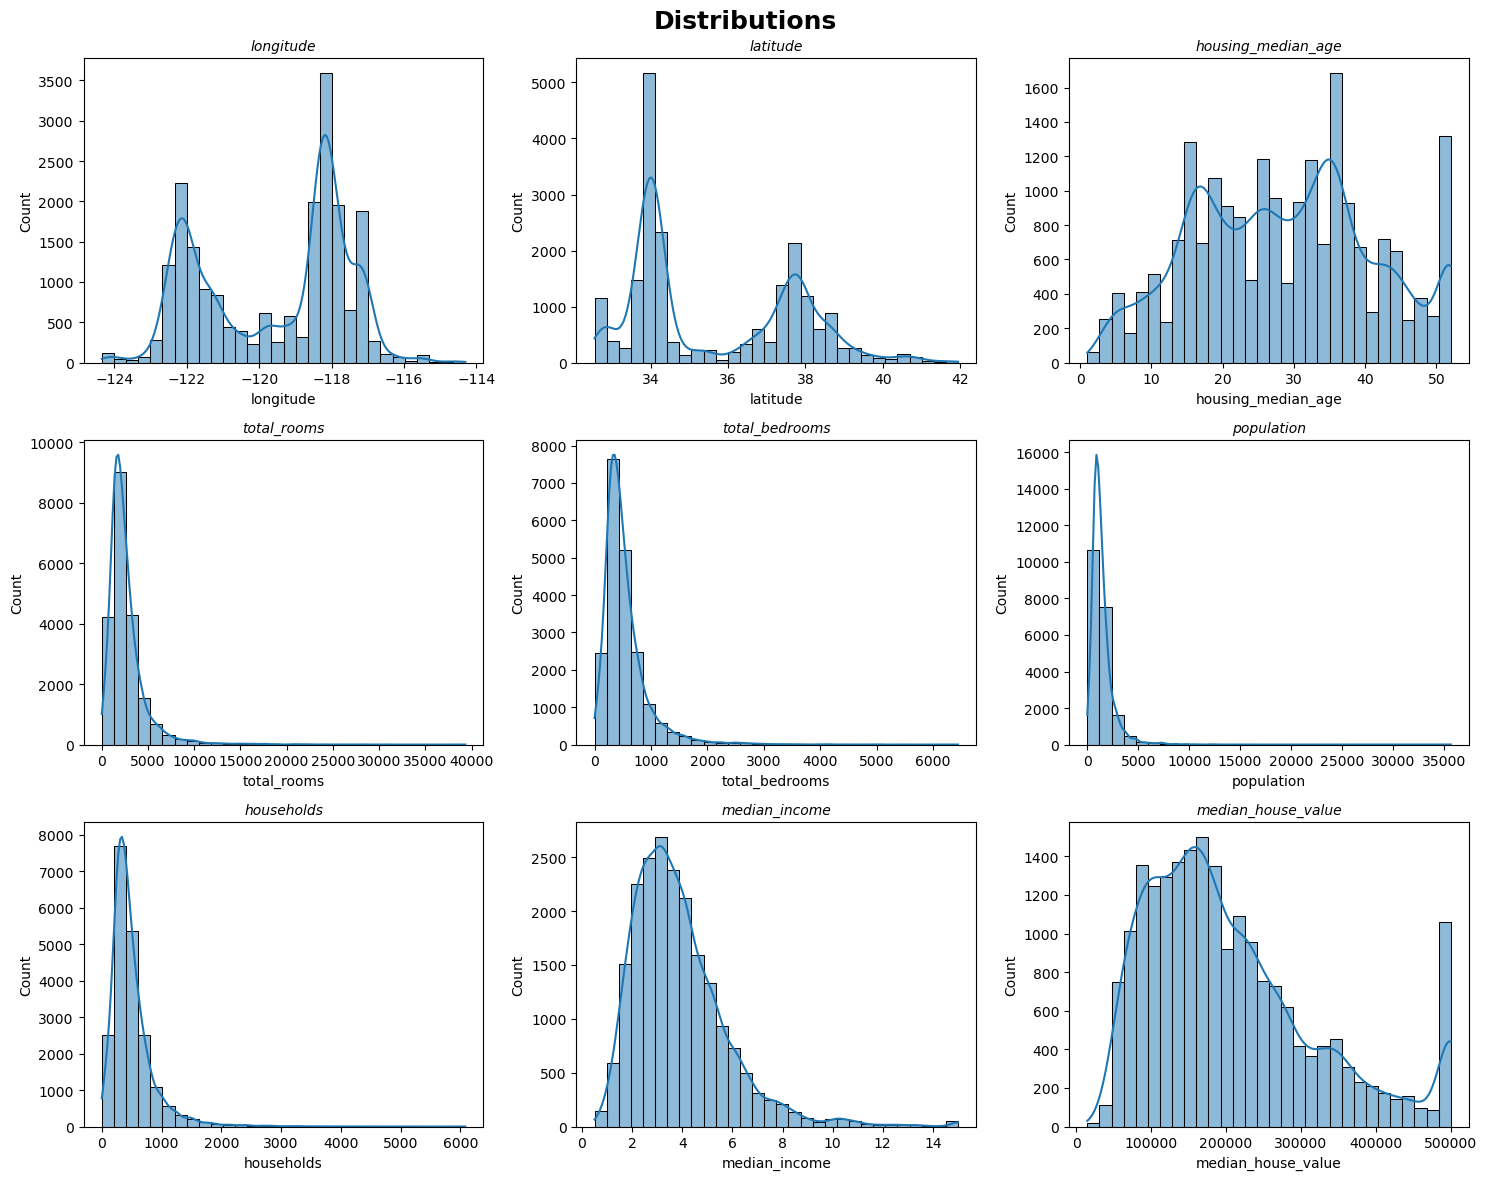

In [13]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(15,12))
fig.suptitle("Distributions", fontsize = 18, fontweight = "bold")

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.histplot(data = df, x = col, kde=True, ax=ax, bins=30)
    ax.set_title(col, fontsize=10, fontstyle = "italic")

plt.tight_layout()
plt.show()

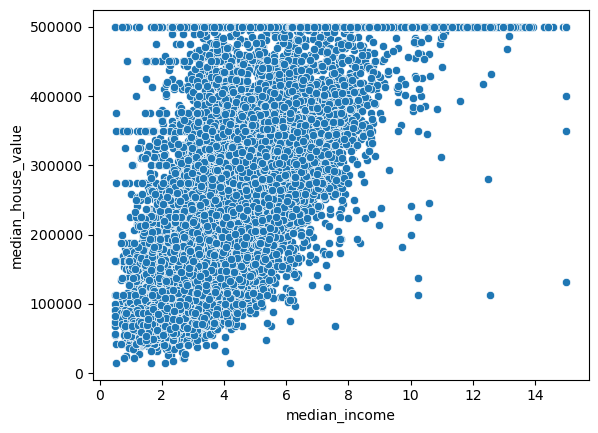

In [14]:
sns.scatterplot(data=df, x = 'median_income', y = 'median_house_value')
plt.show()

In [16]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [21]:
def analyse_outlier_iqr(df, threshold):
    outlier_summary = {}
    numeric_columns = [col for col in df.columns if df[col].dtype != 'O']

    for i in numeric_columns:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - IQR * threshold
        upper = Q3 + IQR * threshold

        outlier = df[ (df[i] < lower) | (df[i] > upper) ]
        outlier_summary[i] = {
            'outliers' : outlier.shape[0],
            'outliers_percantage' : 100 * outlier.shape[0] / df.shape[0],
            'lower' : lower,
            'upper' : upper
        }

    return pd.DataFrame(outlier_summary)

In [28]:
analyse_outlier_iqr(df, 1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outliers,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outliers_percantage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [29]:
def remove_target_outlier(df, target, threshold):
    Q1 = df[target].quantile(0.25)
    Q3 = df[target].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - IQR * threshold
    upper = Q3 + IQR * threshold

    return df[ (df[target] >= lower ) & (df[target] <= upper ) ]

In [31]:
df_target_clean = remove_target_outlier(df, 'median_house_value', threshold=1.5)

In [33]:
df_target_clean.shape

(19569, 10)

In [34]:
df.shape

(20640, 10)

In [37]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


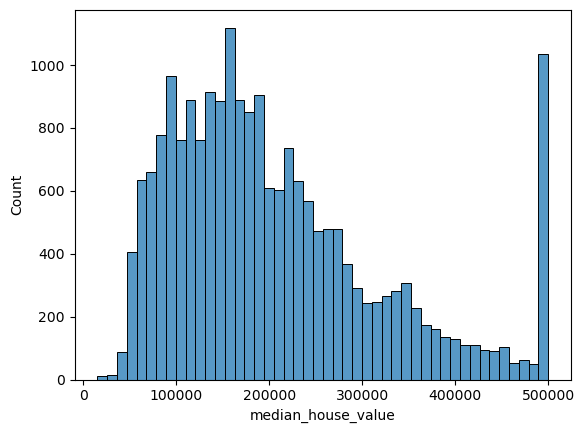

In [38]:
sns.histplot(df, x='median_house_value')
plt.show()

In [51]:
df_target_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19569 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19569 non-null  float64
 1   latitude            19569 non-null  float64
 2   housing_median_age  19569 non-null  float64
 3   total_rooms         19569 non-null  float64
 4   total_bedrooms      19369 non-null  float64
 5   population          19569 non-null  float64
 6   households          19569 non-null  float64
 7   median_income       19569 non-null  float64
 8   median_house_value  19569 non-null  float64
 9   ocean_proximity     19569 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [52]:
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [57]:
df_target_clean.total_bedrooms = df_target_clean.total_bedrooms.fillna(df_target_clean.total_bedrooms.median())

C:\Users\Ali İhsan Sancar\AppData\Local\Temp\ipykernel_10944\1504421666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target_clean.total_bedrooms = df_target_clean.total_bedrooms.fillna(df_target_clean.total_bedrooms.median())


In [58]:
df_target_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000
mean,-119.562786,35.654159,28.352752,2619.977260,538.841739,1442.788952,501.394859,3.665568,190852.301906
std,2.005764,2.151007,12.497772,2183.419302,420.612109,1145.011369,383.396308,1.557927,95438.555669
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,299.000000,797.000000,282.000000,2.522700,116200.000000
50%,-118.510000,34.270000,28.000000,2110.000000,437.000000,1181.000000,411.000000,3.441200,173200.000000
75%,-117.990000,37.730000,37.000000,3123.000000,645.000000,1749.000000,606.000000,4.572100,246700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,482200.000000


In [59]:
df_target_clean.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [61]:
df_target_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19569 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19569 non-null  float64
 1   latitude            19569 non-null  float64
 2   housing_median_age  19569 non-null  float64
 3   total_rooms         19569 non-null  float64
 4   total_bedrooms      19569 non-null  float64
 5   population          19569 non-null  float64
 6   households          19569 non-null  float64
 7   median_income       19569 non-null  float64
 8   median_house_value  19569 non-null  float64
 9   ocean_proximity     19569 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [62]:
df_target_clean['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8552
INLAND        6519
NEAR OCEAN    2419
NEAR BAY      2074
ISLAND           5
Name: count, dtype: int64

In [63]:
from sklearn.model_selection import train_test_split

In [66]:
X = df_target_clean.drop('median_house_value', axis=1)
y = df_target_clean['median_house_value']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=36, test_size=0.33)

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [69]:
onehot = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), ['ocean_proximity'])
    ],
     remainder='passthrough'
)

In [70]:
X_train = onehot.fit_transform(X_train)
X_test = onehot.transform(X_test)

In [72]:
X_train

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 8.2300e+02, 3.1600e+02,
        1.8993e+00],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0610e+03, 3.9000e+02,
        3.5242e+00],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 7.3700e+02, 2.7900e+02,
        5.5842e+00],
       ...,
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.1150e+03, 3.5800e+02,
        3.9091e+00],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 7.6100e+02, 2.4100e+02,
        7.2137e+00],
       [0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 4.2500e+02, 2.0700e+02,
        2.5625e+00]])

In [71]:
col_names = onehot.get_feature_names_out()

In [73]:
X_train = pd.DataFrame(X_train, columns=col_names)
X_test = pd.DataFrame(X_test, columns=col_names)

In [74]:
X_train.head()

,onehot__ocean_proximity_INLAND,onehot__ocean_proximity_ISLAND,onehot__ocean_proximity_NEAR BAY,onehot__ocean_proximity_NEAR OCEAN,remainder__longitude,remainder__latitude,remainder__housing_median_age,remainder__total_rooms,remainder__total_bedrooms,remainder__population,remainder__households,remainder__median_income
0,0.0,0.0,0.0,1.0,-124.10,40.95,17.0,1485.0,345.0,823.0,316.0,1.8993
1,1.0,0.0,0.0,0.0,-121.42,37.75,33.0,1999.0,368.0,1061.0,390.0,3.5242
2,0.0,0.0,0.0,0.0,-116.77,33.08,13.0,1406.0,260.0,737.0,279.0,5.5842
3,0.0,0.0,0.0,0.0,-118.31,33.89,37.0,2278.0,508.0,1257.0,498.0,3.7639
4,0.0,0.0,0.0,1.0,-117.26,33.04,16.0,3109.0,450.0,1433.0,453.0,6.6319


In [76]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# XGBoost Regressor

In [77]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [78]:
from sklearn.metrics import r2_score

In [87]:
y_pred = xgb.predict(X_test)
print("Test Data R2 score:", r2_score(y_test, y_pred))
y_pred_train = xgb.predict(X_train)
print("Train Data R2 score:", r2_score(y_train, y_pred_train))

Test Data R2 score: 0.7989691539573918
Train Data R2 score: 0.934924099328124


# LightGBM Regressor

In [84]:
lgb = LGBMRegressor()
lgb.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000431 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 13111, number of used features: 11
[LightGBM] [Info] Start training from score 190695.964991


LGBMRegressor()

In [86]:
y_pred = lgb.predict(X_test)
print("Test Data R2 score:", r2_score(y_test, y_pred))
y_pred_train = xgb.predict(X_train)
print("Train Data R2 score:", r2_score(y_train, y_pred_train))

Test Data R2 score: 0.8043007192923104
Train Data R2 score: 0.934924099328124


# Boxcox Transformation and Hyparameter Tuning

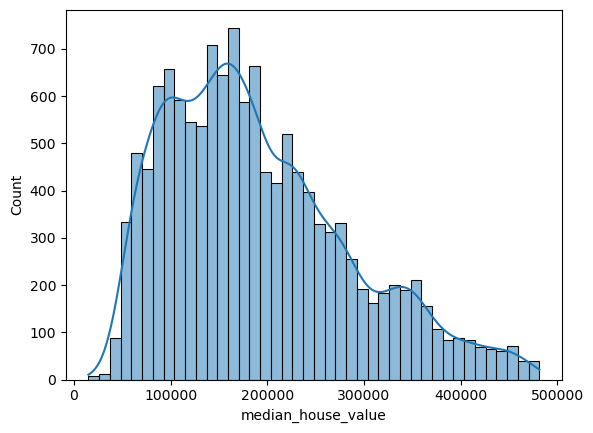

In [93]:
sns.histplot(y_train, kde=True)
plt.show()

In [100]:
from scipy.stats import boxcox
from sklearn.model_selection import RandomizedSearchCV

In [95]:
y_train_transformed, lambda_y = boxcox(y_train)

### XGBoost After Transformed

In [96]:
xgbTransformed = XGBRegressor()
xgbTransformed.fit(X_train, y_train_transformed)
y_pred_transformed = xgbTransformed.predict(X_test)

In [97]:
# (inverse Box-Cox)
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [98]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [99]:
print("Test Data R2 score:", r2_score(y_test, y_pred_original))

Test Data R2 score: 0.798982977768734


In [104]:
params = {
    'n_estimators' : [10, 30, 50, 100, 200, 300, 500],
    'max_depth' : [1, 3, 5, 10, 20, 30],
    'max_leaves' : [3, 15, 31, 63, 127, 512],
    'learning_rate' : [0.1, 0.05, 1],
    'reg_lambda' : [0, 0.5, 1, 1.5],
    'reg_alpha' : [0, 0.5, 1, 1.5],
    'subsample' : [0.5, 0.8, 1.0],
    'colsample_bytree' : [0.5, 0.8, 1.0]
}

In [105]:
randomXGBoost = RandomizedSearchCV(
    estimator=XGBRegressor(),
    param_distributions=params,
    scoring = 'r2',
    verbose = 0,
    cv = 5,
    n_jobs=-1
)

In [106]:
randomXGBoost.fit(X_train, y_train_transformed)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.5, 0.8, 1.0],
                                        'learning_rate': [0.1, 0.05, 1],
                                        'max_depth': [1, 3, 5, 10, 20, 30],
                                        'max_leaves': [3, 15, 31, 63, 127, 512],
                                        'n_estimators': [10, 30, 50, 100, 200,
                                                         300, 500],
                                        'reg_alpha': [0, 0.5, 1, 1.5],
                                        'reg_lambda': [0, 0.5, 1, 1.5],
                                        'subsample': [0.5, 0.8, 1.0]},
                   scoring='r2')

In [107]:
y_pred_transformed = randomXGBoost.predict(X_test)

In [108]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)
print("Test Data R2 score:", r2_score(y_test, y_pred_original))

Test Data R2 score: 0.8080200393118762


In [109]:
randomXGBoost.best_params_

{'subsample': 1.0,
 'reg_lambda': 1,
 'reg_alpha': 0.5,
 'n_estimators': 500,
 'max_leaves': 63,
 'max_depth': 10,
 'learning_rate': 0.05,
 'colsample_bytree': 0.5}

### LightGBM After Transformed

In [110]:
params = {
    'n_estimators' : [50, 100, 300, 500],
    'num_leaves' : [15, 31, 63, 127, 3],
    'max_depth' : [5, 10, 20, 30, 50, 100],
    'learning_rate' : [0.1, 0.05, 1],
    'subsample' : [1.0, 0.8, 0.5],
    'colsample_bytree' : [1.0, 0.8, 0.5],
    'reg_alpha' : [0.0, 0.5, 1.0, 1.5],
    'reg_lambda' : [0.0, 0.5, 1.0, 1.5]
}

In [111]:
randomLGBM = RandomizedSearchCV(
    estimator=LGBMRegressor(),
    param_distributions=params,
    verbose=0,
    cv = 5,
    scoring='r2',
    n_jobs=-1
)

In [112]:
randomLGBM.fit(X_train, y_train_transformed)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000301 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 13111, number of used features: 11
[LightGBM] [Info] Start training from score 78.530312


RandomizedSearchCV(cv=5, estimator=LGBMRegressor(), n_jobs=-1,
                   param_distributions={'colsample_bytree': [1.0, 0.8, 0.5],
                                        'learning_rate': [0.1, 0.05, 1],
                                        'max_depth': [5, 10, 20, 30, 50, 100],
                                        'n_estimators': [50, 100, 300, 500],
                                        'num_leaves': [15, 31, 63, 127, 3],
                                        'reg_alpha': [0.0, 0.5, 1.0, 1.5],
                                        'reg_lambda': [0.0, 0.5, 1.0, 1.5],
                                        'subsample': [1.0, 0.8, 0.5]},
                   scoring='r2')

In [113]:
y_pred_transformed = randomLGBM.predict(X_test)

In [114]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [115]:
print("Test Data R2 score:", r2_score(y_test, y_pred_original))

Test Data R2 score: 0.8153825211959715
